this notebook runs both cyto3 and cellpose-sam so uses cellpose==3.1.1.2 with the cellpose-sam net hacked in

(see example env setup in benchmark_all_sam.ipynb)

In [1]:
import numpy as np
from cellpose import io, metrics, models, utils, transforms, denoise
import time
from tqdm import trange
from pathlib import Path
from natsort import natsorted
import tifffile
import matplotlib.pyplot as plt
import benchmarks

files, imgs, masks_true = benchmarks.load_dataset("cyto2")
diam_true = np.array([utils.diameters(m)[0] for m in masks_true])

In [6]:
imgs[0].shape

(2, 383, 512)

## size

In [21]:
import cv2
import torch
from cellpose import models, io
#from train_subsets import TransformerMP
io.logger_setup()

device = torch.device("cuda")

mtype = "cellsam"

if mtype=="cpsam" or mtype=="cpdino":
    if mtype=="cpdino":
        mname = "/home/carsen/dm11_string/datasets_cellpose/models/cp2000_0.0002_0.4_0.1_84002256"
    else:
        mname = "/home/carsen/dm11_string/datasets_cellpose/models/cpsam8_2000_162519454"
    model = models.CellposeModel(gpu=True, pretrained_model=mname)
    channels = None
    augment = False
    tile_overlap = 0.1
elif mtype=="cyto3":
    model = models.CellposeModel(gpu=True, model_type="cyto3")
    channels = [2, 3]
    augment = True 
    tile_overlap = 0.5
elif mtype=="cellsam":
    from cellSAM import cellsam_pipeline
    

masks_preds = []
aps = []
for sz in [30]:#[10, 15, 30, 60, 90]:
    diameters = diam_true.copy() * (30. / sz)
    imgs_rsz = [transforms.resize_image(imgs[i].transpose(1,2,0), rsz=30./diameters[i]).transpose(2,0,1) for i in range(len(imgs))]
    masks_true_rsz = [transforms.resize_image(masks_true[i], rsz=30./diameters[i], no_channels=True, interpolation=cv2.INTER_NEAREST) for i in range(len(imgs))]

    if mtype!="cellsam":
        masks_pred, flows, styles = model.eval(imgs_rsz, diameter=30., 
                                               channels=channels, augment=augment, 
                                               tile_overlap=tile_overlap, batch_size=64,
                                               flow_threshold=0.4, cellprob_threshold=0)
    else:
        if sz!=90:
            masks_pred = []
            bsize = 1024
            for i in trange(len(imgs_rsz)):
                img = np.concatenate((imgs_rsz[i][:1]*0, imgs_rsz[i][::-1]), axis=0)
                Ly, Lx = img.shape[1:]
                Lyr = bsize if Ly > bsize and Ly > Lx else Ly
                Lxr = bsize if Lx > bsize and Lx >= Ly else Lx
                Lxr = int(np.round(bsize * (Lx / Ly))) if Ly > Lx and Lyr==bsize else Lxr
                Lyr = int(np.round(bsize * (Ly / Lx))) if Lx >= Ly and Lxr==bsize else Lyr
                if Lyr != Ly or Lxr != Lx:
                    img = cv2.resize(img.transpose(1, 2, 0), (Lxr, Lyr), interpolation=cv2.INTER_LINEAR).transpose(2, 0, 1)
                if Lyr < bsize or Lxr < bsize:
                    padyx = [(int(np.floor((bsize-Lyr)/2)), int(np.ceil((bsize-Lyr)/2))),
                            (int(np.floor((bsize-Lxr)/2)), int(np.ceil((bsize-Lxr)/2)))]
                    img = np.pad(img, ((0,0), padyx[0], padyx[1]), mode='constant')
                else:
                    padyx = [(0, 0), (0, 0)]
                try:
                    masks = cellsam_pipeline(img, use_wsi=False)
                except:
                    masks = np.zeros((bsize, bsize), dtype="uint16")
                masks = masks[padyx[0][0]:bsize-padyx[0][1], padyx[1][0]:bsize-padyx[1][1]]
                if Lyr != Ly or Lxr != Lx:
                    masks = cv2.resize(masks, (Lx, Ly), interpolation=cv2.INTER_NEAREST)
                masks_pred.append(masks)
                
        
    break

    ap, tp, fp, fn = metrics.average_precision(masks_true_rsz, masks_pred)
    if sz==90 and mtype=="cellsam":
        ap *= np.nan
    else:
        print(ap.mean(axis=0))
    
np.save(f"results/size_invariance_{mtype}.npy", {"ap": ap, "masks_pred": masks_pred})

2026-05-13 15:05:18,623 [INFO] WRITING LOG OUTPUT TO /home/carsen/.cellpose/run.log
2026-05-13 15:05:18,623 [INFO] 
cellpose version: 	3.1.1.2 
platform:       	linux 
python version: 	3.11.15 
torch version:  	2.11.0+cu130


  0%|          | 0/67 [00:00<?, ?it/s]/media/carsen/disk1/github/cellSAM/cellSAM/sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")
  1%|▏         | 1/67 [00:01<01:34,  1.43s/it]/media/carsen/disk1/github/cellSAM/cellSAM/sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")
  3%|▎         | 2/67 [00:02<01:33,  1.43s/it]/media/carsen/disk1/github/cellSAM/cellSAM/sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")
  6%|▌         | 4/67 [00:05<01:29,  1.43s/it]/media/carsen/disk1/github/cellSAM/cellSAM/sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  warnings.warn("Low IOU threshold, ignoring mask.")
 16%|█▋        | 11/67 [00:14<01:11,  1.28s/it]/media/carsen/disk1/github/cellSAM/cellSAM/sam_inference.py:351: UserWarning: Low IOU threshold, ignoring mask.
  war

NameError: name 'ap' is not defined

In [23]:
    ap, tp, fp, fn = metrics.average_precision(masks_true_rsz, masks_pred)
    ap.mean(axis=0)

array([0.5795783 , 0.24078326, 0.01909851], dtype=float32)

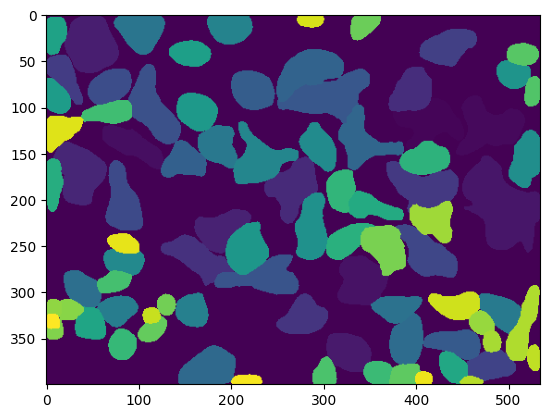

In [20]:
plt.imshow(masks)

In [15]:
# fixed config (argparse removed; values set to former parser defaults)
cfg = {
    "save_name": "",
    "save_folder": "results/evals",
    "dataset_name": "",
    "bbox_threshold": 0.4,
    "iou_threshold": 0.4,
    "mask_threshold": 0.5,
    "is_debug": 0,
    "sam_locator": "anchor",
    "sam_prompts": ["box"],
    "model_name": "",
    "num_query_position": 3500,
    "num_query_pattern": 1,
    "ckpt": "",
    "dataloader_root": "",
    "cellpose_model_type": "",

    # model/runtime config
    "unfrozen_sam_parts": "",
    "freeze_cellfinder": True,
    "spatial_prior": "learned",
    "data": {"img_size": "orig"},
    "sum_on_scores": False,
    "enc_layers": 6,
    "dec_layers": 6,
    "dim_feedforward": 1024,
    "hidden_dim": 256,
    "dropout": 0.0,
    "nheads": 8,
    "attention_type": "RCDA",
    "num_feature_levels": 1,
    "device": "cuda",
    "seed": 42,
    "num_classes": 2,
    "model": {"pretrain": 0},
}


In [ ]:
from cellSAM import CellSAM

from cellSAM.model import get_model

# app = CellSAM(cfg)
# app.target_image_size = "crop_512" # TODO: seems to be unused
# app.load_state_dict(torch.load(args.ckpt, map_location=torch.device('cpu')), strict=False)
# app = app.eval().cuda()

In [18]:
get_model?

Signature: get_model(model='cellsam_general', version=None) -> torch.nn.modules.module.Module
Docstring:
Returns a loaded CellSAM model.

If pretrained model weights specified by ``version`` are not found locally,
they will be downloaded from users.deepcell.org.

Parameters
----------
model : str, default="cellsam_general"
   Which model to load. Options include:

    - ``"cellsam_general"``
    - ``"cellsam_extra"``

   ``"cellsam_general"`` is trained only on datasets that are referenced in
   the original publication and is made available for reproducibility.
   Use this model to reproduce the model evaluation results cited in the
   publication and achieve strong performance in the domains covered in the
   paper.

   ``"cellsam_extra"`` incorporates additional datasets and, therefore, is
   recommended for domains that extend beyond those covered in the paper.

version : str, optional. Default=latest
   Which version of the model to use. When ``version=None`` (the default),
   the

In [11]:
masks_pred

[array([], shape=(0, 35), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], shape=(0, 0), dtype=uint16),
 array([], s

In [9]:
segment_cellular_image(model, img)

NameError: name 'model' is not defined

## noise

In [ ]:
# !pip install cellpose==

  Using cached cellpose-4.0.1-py3-none-any.whl.metadata (21 kB)
Using cached cellpose-4.0.1-py3-none-any.whl (209 kB)
  Attempting uninstall: cellpose
    Found existing installation: cellpose 4.1.1
    Uninstalling cellpose-4.1.1:
      Successfully uninstalled cellpose-4.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openscope-databook 0.1.0 requires numpy==1.26.0, but you have numpy 2.2.6 which is incompatible.
openscope-databook 0.1.0 requires torch==2.5.1, but you have torch 2.11.0+cu128 which is incompatible.


In [5]:
import torch
device = torch.device("cuda")
mtype = "cpsam"
channels = None 
augment = False 
tile_overlap = 0.1
io.logger_setup()
# model = models.CellposeModel(gpu=True, pretrained_model="cpsam")

nstr = {"poisson": "denoise", "blur": "deblur", "downsample": "upsample", "aniso": "aniso"}
for ii, noise_type in enumerate(["poisson", "blur", "downsample", "aniso"]):
    #if noise_type != "downsample":
    #    continue
    masks_preds = [[], [], []]
    aps = []
    if mtype=="cp3":
        mstr = "cyto3" if noise_type!="aniso" else "cyto2"
        dn_model = denoise.DenoiseModel(gpu=True, model_type=f"{nstr[noise_type]}_{mstr}", chan2=True)
    print(noise_type)
    if noise_type=="poisson":
        param = np.array([5, 2.5, 0.5])
    elif noise_type=="blur":
        param = np.array([2, 4, 8])# 48])
    elif noise_type=="downsample":
        param = np.array([2, 5, 10])
    elif noise_type=="aniso":
        param = np.array([2, 6, 12])
    print(param)
    
    denoise.deterministic()
    for k in range(len(param)):
        for i in trange(len(imgs)):
            img = np.maximum(0, imgs[i].copy())
            if noise_type=="poisson":
                params = {"poisson": 1.0, "blur": 0.0, "downsample": 0.0, "pscale": param[k]}
            elif noise_type=="blur":
                params = {"poisson": 1.0, "pscale": 120., "blur": 1.0, "downsample": 0.0,
                            "sigma0": param[k], "sigma1": param[k]}
            elif noise_type=="downsample":
                params = {"poisson": 0.0, "pscale": 0., "blur": 1.0, "downsample": 1.0, "ds": param[k],
                            "sigma0": param[k]/2, "sigma1": param[k]/2}
            else:
                params = {"poisson": 0.0, "pscale": 0., "blur": 1.0, "downsample": 1.0, "ds": param[k],
                            "sigma0": param[k]/2, "sigma1": param[k]/2*0, "iso": False}
            
            img = denoise.add_noise(torch.from_numpy(img).unsqueeze(0),
                                    **params).cpu().numpy().squeeze()

            if mtype != "cellsam":
                if mtype == "cp3":
                    if noise_type=="downsample" or noise_type=="aniso":
                        img_rsz = transforms.resize_image(img.transpose(1,2,0).copy(), rsz=30./diam_true[i]).transpose(2,0,1)
                    else:
                        img_rsz = img.copy()
                    diameter = diam_true[i] if noise_type!="downsample" and noise_type!="aniso" else None
                    img = dn_model.eval(img_rsz[[1,2]], diameter=diameter, channels=[1,2], channel_axis=0)
                elif mtype == "cyto3":
                    diameter = diam_true[i]
                else:
                    diameter = 30.

                masks_pred0, flows, styles = model.eval(img, diameter=diameter, channels=channels, augment=augment,
                                                 tile_overlap=tile_overlap, batch_size=64, normalize=False)
                if masks_pred0.shape[0] != img.shape[1] or masks_pred0.shape[1] != img.shape[2]:
                    masks_pred0 = transforms.resize_image(masks_pred0, Ly=img.shape[1], Lx=img.shape[2], no_channels=True, interpolation=cv2.INTER_NEAREST)
                
                masks_preds[k].append(masks_pred0)
                
            else:
                bsize = 512
                img = img[[0,2,1]].copy()
                Ly, Lx = img.shape[1:]
                Lyr = bsize if Ly > bsize and Ly > Lx else Ly
                Lxr = bsize if Lx > bsize and Lx >= Ly else Lx
                Lxr = int(np.round(bsize * (Lx / Ly))) if Ly > Lx and Lyr==bsize else Lxr
                Lyr = int(np.round(bsize * (Ly / Lx))) if Lx >= Ly and Lxr==bsize else Lyr
                if Lyr != Ly or Lxr != Lx:
                    img = cv2.resize(img.transpose(1, 2, 0), (Lxr, Lyr), interpolation=cv2.INTER_LINEAR).transpose(2, 0, 1)
                if Lyr < bsize or Lxr < bsize:
                    padyx = [(int(np.floor((bsize-Lyr)/2)), int(np.ceil((bsize-Lyr)/2))),
                            (int(np.floor((bsize-Lxr)/2)), int(np.ceil((bsize-Lxr)/2)))]
                    img = np.pad(img, ((0,0), padyx[0], padyx[1]), mode='constant')
                else:
                    padyx = [(0, 0), (0, 0)]
                try:
                    masks, _, _ = segment_cellular_image(img, device='cuda')
                except:
                    masks = np.zeros((bsize, bsize), dtype="uint16")
                masks = masks[padyx[0][0]:bsize-padyx[0][1], padyx[1][0]:bsize-padyx[1][1]]
                if Lyr != Ly or Lxr != Lx:
                        masks = cv2.resize(masks, (Lx, Ly), interpolation=cv2.INTER_NEAREST)
                masks_pred0 = masks
            
            
        aps.append(metrics.average_precision(masks_true, masks_preds[k])[0])
            # aps[k].append(ap)
        print(aps[k][:,0].mean())

    np.save(f"results/{noise_type}_invariance_{mtype}.npy", {"aps": aps, "masks_preds": masks_preds})

[GUI INFO] : WRITING LOG OUTPUT TO /home/carsen/.cellpose/run.log

cellpose version: 	4.1.2.dev36+gda245fd.d20260513 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.11.0+cu128
2026-05-12 23:03:15,601 [io INFO] WRITING LOG OUTPUT TO /home/carsen/.cellpose/run.log
2026-05-12 23:03:15,602 [io INFO] 
cellpose version: 	4.1.2.dev36+gda245fd.d20260513 
platform:       	linux 
python version: 	3.11.13 
torch version:  	2.11.0+cu128
poisson
[5.  2.5 0.5]


100%|██████████| 67/67 [00:07<00:00,  9.19it/s]


0.7530614


100%|██████████| 67/67 [00:07<00:00,  9.42it/s]


0.6993855


...

0.7802379


100%|██████████| 67/67 [00:07<00:00,  8.65it/s]


0.77159125


100%|██████████| 67/67 [00:07<00:00,  8.61it/s]


0.692578


In [4]:
metrics.average_precision(masks_true, masks_preds[k])[0].shape

(67, 3)

In [32]:
        print(aps[k][0][:,0].mean())


0.73517084


In [31]:
aps[k][0]

array([[0.8876405 , 0.75      , 0.05      ],
       [0.8452381 , 0.8023256 , 0.12318841],
       [0.9339623 , 0.6666667 , 0.025     ],
       [0.9787234 , 0.8235294 , 0.25675675],
       [0.9310345 , 0.75      , 0.07692308],
       [1.        , 0.6       , 0.        ],
       [0.9019608 , 0.67241377, 0.12790698],
       [0.8863636 , 0.66      , 0.09210526],
       [0.9285714 , 0.6530612 , 0.03846154],
       [0.9285714 , 0.9285714 , 0.2857143 ],
       [1.        , 0.9166667 , 0.3939394 ],
       [0.8611111 , 0.52272725, 0.01515152],
       [0.21917808, 0.04705882, 0.        ],
       [0.38967136, 0.218107  , 0.        ],
       [0.4903047 , 0.11850312, 0.        ],
       [0.97590363, 0.53271025, 0.        ],
       [0.85106385, 0.22535211, 0.        ],
       [0.90384614, 0.13793103, 0.        ],
       [0.8852459 , 0.796875  , 0.19791667],
       [0.8965517 , 0.5277778 , 0.        ],
       [0.79787236, 0.4695652 , 0.03048781],
       [0.80508476, 0.23121387, 0.        ],
       [0.

In [26]:
metrics.average_precision(masks_true, masks_preds[k])[0].mean(axis=0)

array([0.7351708 , 0.46696687, 0.07486285], dtype=float32)

In [21]:
metrics.average_precision(masks_true[i], masks_pred0)

(array([0.779661  , 0.22093023, 0.        ], dtype=float32),
 array([92., 38.,  0.], dtype=float32),
 array([ 7., 61., 99.], dtype=float32),
 array([ 19.,  73., 111.], dtype=float32))

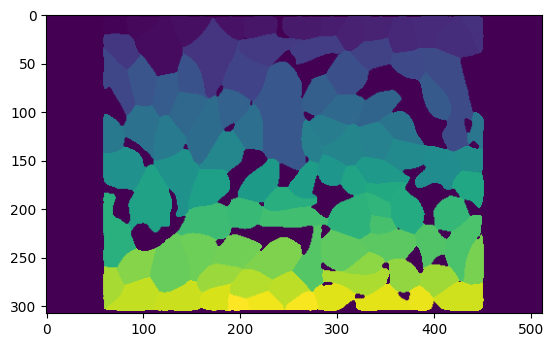

In [19]:
plt.imshow(masks_pred0)

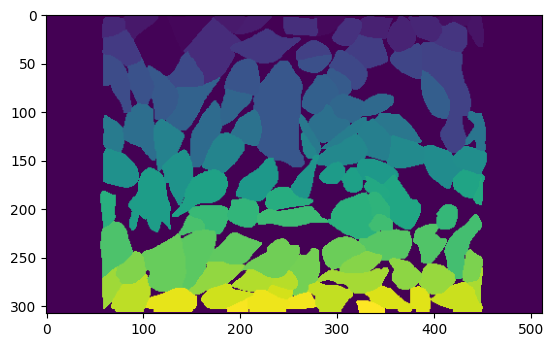

In [20]:
plt.imshow(masks_true[i])

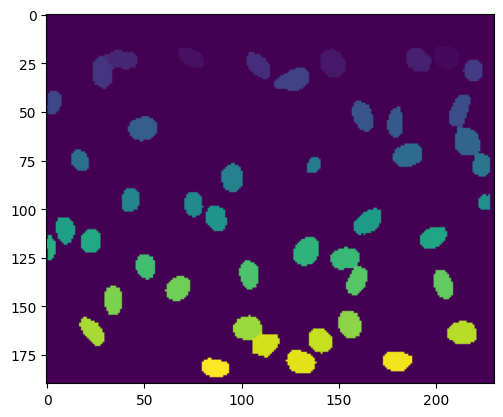

In [17]:
plt.imshow(masks_pred0)

In [ ]:
from cellSAM import segment_cellular_image
from cellpose import resnet_torch
import cv2
import torch
io.logger_setup()

device = torch.device("cuda")

ps = 8
backbone = "vit_l"
net = TransformerMP(ps=ps, backbone=backbone).to(device)
net.load_model("models/cpsam8_0_2100_8_402175188", strict=False, multigpu=False)

model = models.CellposeModel(gpu=True, nchan=3)
net.eval()
model.net = net

cp_model = models.CellposeModel(gpu=True, model_type="cyto3")


nstr = {"poisson": "denoise", "blur": "deblur", "downsample": "upsample", "aniso": "aniso"}
for ii, noise_type in enumerate(["poisson", "blur", "downsample", "aniso"]):
    #if noise_type != "downsample":
    #    continue
    masks_preds = [[], [], []]
    dat = np.load(f"{noise_type}_invariance.npy", allow_pickle=True).item()
    aps = dat["aps"]
    masks_preds = dat["masks_preds"]
    #aps = np.zeros((4, 3, len(imgs), 3))
    mstr = "cyto3" if noise_type!="aniso" else "cyto2"
    dn_model = denoise.DenoiseModel(gpu=True, model_type=f"{nstr[noise_type]}_{mstr}", chan2=True)
    print(noise_type)
    if noise_type=="poisson":
        param = np.array([5, 2.5, 0.5])
    elif noise_type=="blur":
        param = np.array([2, 4, 8])# 48])
    elif noise_type=="downsample":
        param = np.array([2, 5, 10])
    elif noise_type=="aniso":
        param = np.array([2, 6, 12])
    print(param)
    ap = np.zeros((len(imgs), len(param)))

    denoise.deterministic()
    importlib.reload(denoise)
    for k in range(len(param)):
        for i in trange(len(imgs)):
            img = np.maximum(0, imgs[i].copy())
            if noise_type=="poisson":
                params = {"poisson": 1.0, "blur": 0.0, "downsample": 0.0, "pscale": param[k]}
            elif noise_type=="blur":
                params = {"poisson": 1.0, "pscale": 120., "blur": 1.0, "downsample": 0.0,
                            "sigma0": param[k], "sigma1": param[k]}
            elif noise_type=="downsample":
                params = {"poisson": 0.0, "pscale": 0., "blur": 1.0, "downsample": 1.0, "ds": param[k],
                            "sigma0": param[k]/2, "sigma1": param[k]/2}
            else:
                params = {"poisson": 0.0, "pscale": 0., "blur": 1.0, "downsample": 1.0, "ds": param[k],
                            "sigma0": param[k]/2, "sigma1": param[k]/2*0, "iso": False}
            img = denoise.add_noise(torch.from_numpy(img).unsqueeze(0),
                                    **params).cpu().numpy().squeeze()

            for j in range(1):
                if j==0:
                    masks_pred0, flows, styles = model.eval(img, diameter=30., channels=None, augment=False,
                                                    bsize=256, tile_overlap=0.1, batch_size=64,
                                                    flow_threshold=0.4, cellprob_threshold=0, normalize=False)
                    masks_preds[k].append(masks_pred0)
                elif j==1:
                    masks_pred0, flows, styles = cp_model.eval(img, diameter=diam_true[i], channels=[2,3],
                                                    bsize=224, tile_overlap=0.5, batch_size=64, augment=True,
                                                    flow_threshold=0.4, cellprob_threshold=0, normalize=False)
                elif j==2:
                    if noise_type=="downsample" or noise_type=="aniso":
                        img_rsz = transforms.resize_image(img.transpose(1,2,0).copy(), rsz=30./diam_true[i]).transpose(2,0,1)
                    else:
                        img_rsz = img.copy()
                    img_dn = dn_model.eval(img_rsz[[1,2]], diameter=None, channels=[1,2], channel_axis=0)
                    masks_pred0, flows, styles = cp_model.eval(img_dn, diameter=diam_true[i] if noise_type!="downsample" and noise_type!="aniso" else None,
                                                               channels=[1,2],
                                                    bsize=224, tile_overlap=0.5, batch_size=64, augment=True,
                                                    flow_threshold=0.4, cellprob_threshold=0, normalize=False)
                    masks_pred0 = transforms.resize_image(masks_pred0, Ly=img.shape[1], Lx=img.shape[2], no_channels=True, interpolation=cv2.INTER_NEAREST)
                    #plt.imshow(masks_pred0)
                    #plt.show()
                else:
                    bsize = 512
                    img = img[[0,2,1]].copy()
                    Ly, Lx = img.shape[1:]
                    Lyr = bsize if Ly > bsize and Ly > Lx else Ly
                    Lxr = bsize if Lx > bsize and Lx >= Ly else Lx
                    Lxr = int(np.round(bsize * (Lx / Ly))) if Ly > Lx and Lyr==bsize else Lxr
                    Lyr = int(np.round(bsize * (Ly / Lx))) if Lx >= Ly and Lxr==bsize else Lyr
                    if Lyr != Ly or Lxr != Lx:
                        img = cv2.resize(img.transpose(1, 2, 0), (Lxr, Lyr), interpolation=cv2.INTER_LINEAR).transpose(2, 0, 1)
                    if Lyr < bsize or Lxr < bsize:
                        padyx = [(int(np.floor((bsize-Lyr)/2)), int(np.ceil((bsize-Lyr)/2))),
                                (int(np.floor((bsize-Lxr)/2)), int(np.ceil((bsize-Lxr)/2)))]
                        img = np.pad(img, ((0,0), padyx[0], padyx[1]), mode='constant')
                    else:
                        padyx = [(0, 0), (0, 0)]
                    try:
                        masks, _, _ = segment_cellular_image(img, device='cuda')
                    except:
                        masks = np.zeros((bsize, bsize), dtype="uint16")
                    masks = masks[padyx[0][0]:bsize-padyx[0][1], padyx[1][0]:bsize-padyx[1][1]]
                    if Lyr != Ly or Lxr != Lx:
                           masks = cv2.resize(masks, (Lx, Ly), interpolation=cv2.INTER_NEAREST)
                    masks_pred0 = masks
                ap = metrics.average_precision([masks_true[i]], [masks_pred0])[0]
                aps[j,k,i] = ap
        print(aps[:,k,:,0].mean(axis=-1))

    #np.save(f"{noise_type}_invariance.npy", {"aps": aps, "masks_preds": masks_preds})


## color

In [ ]:
device = torch.device("cuda")

ps = 8
backbone = "vit_l"
net = TransformerMP(ps=ps, backbone=backbone).to(device)
net.load_model("models/cpsam8_0_2100_8_402175188", strict=False, multigpu=False)

model = models.CellposeModel(gpu=True, nchan=3)
net.eval()
model.net = net

irgb = [[0,1,2], [2,0,1], [1,2,0], 'random']
rgb_title = ['RGB', 'BRG', 'GBR', 'Random \n each']

aps = []
masks_preds = []
test_data = []
for i in range(4):
    rgb = irgb[i]

    np.random.seed(42)
    test_data_copy = imgs.copy()

    if rgb == 'random':
        for j in range(len(test_data_copy)):
            iswap = np.random.permutation(3)
            test_data_copy[j] = test_data_copy[j][iswap]
    elif rgb is not None:
        for j in range(len(test_data_copy)):
            test_data_copy[j] = test_data_copy[j][rgb]

    masks_pred, flows, styles = model.eval(test_data_copy, normalize = False, tile_overlap = 0.1,
                            bsize = 256,  diameter= None, #1. * diam_test[ind_im],
                            augment = False, channels=None, niter = None, batch_size = 64)

    app0 = metrics.average_precision(masks_true, masks_pred)[0]
    aps.append(app0)
    masks_preds.append(masks_pred)
    test_data.append(test_data_copy)

aps = np.array(aps)

In [ ]:
np.save(f"color_invariance.npy", {"aps": aps, "masks_preds": masks_preds, "test_data": test_data})

In [ ]:
plt.plot(aps[:,:,0].mean(axis=-1))